# CNN Project

##### Title of Project: Ultrasound Fetal Plane Detection
##### Name: Farha K Mohammadunny
##### Organization: Entri Elevate
##### Date: 01/07/2026

### Overview
While doing ultrasound scanning of the pregnant woman, detecting the plane to identify the correct growth and measurement of the fetus is important. By doing this project, the model will predict the fetal plane and using this further while scanning we can use to calculate the growth of the fetus.

### Objective
To develop an accurate and efficient model that detects the fetal plane from the ultrasound images.

### Data Description
- Source: https://zenodo.org/records/3904280
          FETAL_PLANES_DB_data.csv
          Images - 12400
- 6 Classes:
    Fetal Anatomical Planes: Abdomen, Brain (Further categorized into the 3 most common fetal brain planes: Trans-thalamic, Trans-cerebellum, Trans-ventricular), Femur, Thorax.
    Mother’s Cervix.

- General Category: Including any other less common image plane.
- Meta Information: Patient number, US machine, Operator.
- Training-test split used in the Nature Sci Rep paper.

In [2]:
# Import necessary libraries
import os
import json
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [ ]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30

In [ ]:
# Define folder path and parameters
dataset_dir = "FETAL_PLANES_ZENODO" 
csv_path = os.path.join(dataset_dir, "FETAL_PLANES_DB_data.csv")
images_dir = os.path.join(dataset_dir, "Images")

# Output path
output_dir = "Output"
model_dir = os.path.join(output_dir, "Model")
plots_dir = os.path.join(output_dir, "Plots")
metrics_dir = os.path.join(output_dir, "Metrics")
predictions_dir = os.path.join(output_dir, "Predictions")

# Creates each folder if it does not already exist
for folder in [output_dir, model_dir, plots_dir, metrics_dir, predictions_dir]:
    os.makedirs(folder, exist_ok=True)

In [ ]:
# Data Loading
df = pd.read_csv(csv_path, sep=';')
df.columns = df.columns.str.strip()

print(f"Dataset Shape: {df.shape}")
print(f"Dataset Columns: {df.columns.to_list()}")
df.head()

Dataset Shape: (12400, 7)
Dataset Columns: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Train']


,Image_name,Patient_num,Plane,Brain_plane,Operator,US_Machine,Train
0,Patient00001_Plane1_1_of_15,1,Other,Not A Brain,Other,Aloka,1
1,Patient00001_Plane1_2_of_15,1,Other,Not A Brain,Other,Aloka,1
2,Patient00001_Plane1_3_of_15,1,Other,Not A Brain,Other,Aloka,1
3,Patient00001_Plane1_4_of_15,1,Other,Not A Brain,Other,Aloka,1
4,Patient00001_Plane1_5_of_15,1,Other,Not A Brain,Other,Aloka,1


### Data Preprocessing

In [ ]:
# Lists required columns for the classification task
req_features = ['Image_name', 'Plane']

# Checks whether required column exists
for col in req_features:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Keeps only the relevant columns
df = df[['Image_name', 'Plane']].copy()

# Removes rows with missing values
df.dropna(inplace=True)

# Excludes ambiguous 'Other' class
df = df[df['Plane'] != 'Other']

In [ ]:
# Creates full image filename and image path
df['File_name'] = df['Image_name'].astype(str).str.strip() + ".png"
df['File_path'] = df['File_name'].apply(lambda x : os.path.join(images_dir, x))
# Keeps only rows with existing images
df = df[df['File_path'].apply(os.path.exists)].reset_index(drop = True)
df['Plane'].value_counts()

Plane
Fetal brain        3092
Fetal thorax       1718
Maternal cervix    1626
Fetal femur        1040
Fetal abdomen       711
Name: count, dtype: int64

In [ ]:
df.shape

(8187, 4)

### Label Encoding

In [ ]:
le = LabelEncoder()
df['Label_id'] = le.fit_transform(df['Plane'])

class_names = list(le.classes_)
num_classes = len(class_names)

print("Classes : ", class_names)
print("Number of classes : ", num_classes)

Classes :  ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix']
Number of classes :  5


### Data Splitting

In [ ]:
# Three separate dataframes:
# train_df for model training
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['Label_id']
)

# val_df for validation during training
# test_df for final model evaluation
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df['Label_id']
)

print("Train samples : ", len(train_df))
print("Validation samples : ", len(val_df))
print("Test samples : ", len(test_df))

Train samples :  6549
Validation samples :  819
Test samples :  819


### Image Loading Function

In [ ]:
def load_image(file_path, label):
    image = tf.io.read_file(file_path)
    # Decodes image into RGB tensor
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    # Resizes image to configured dimensions
    image = tf.image.resize(image, IMG_SIZE)
    # Normalizes pixel values to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

### Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name = "data_augmentation")

### Dataset Pipeline

In [ ]:
def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe['File_path'].values,
        dataframe['Label_id'].values
    ))

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=1000, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
# Generates training dataset
train_ds = make_dataset(train_df, training=True)
# Generates validation dataset
val_ds = make_dataset(val_df)
# Generates test dataset
test_ds = make_dataset(test_df)

### Model Architecture

In [ ]:
def build_self_designed_cnn(input_shape = (224, 224, 3), num_classes = 5):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    for filters, dropout_rate in [(32, 0.20), (64, 0.25), (128, 0.30), (256, 0.35)]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(dropout_rate)(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="self_designed_cnn")


In [ ]:
model = build_self_designed_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=num_classes
)

In [ ]:
model.summary()

Model: "self_designed_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,02

 Total params: 1,276,453 (4.87 MB)

 Trainable params: 1,274,021 (4.86 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
# Model Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Callback Configuration
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        filepath=os.path.join(model_dir, "best_model.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# Model Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6055 - loss: 1.1388
Epoch 1: val_accuracy improved from None to 0.14530, saving model to Output\Model\best_model.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 944s 5s/step - accuracy: 0.7233 - loss: 0.7848 - val_accuracy: 0.1453 - val_loss: 5.5521 - learning_rate: 0.0010
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8425 - loss: 0.4378
Epoch 2: val_accuracy improved from 0.14530 to 0.28816, saving model to Output\Model\best_model.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 1021s 5s/step - accuracy: 0.8545 - loss: 0.4162 - val_accuracy: 0.2882 - val_loss: 3.7106 - learning_rate: 0.0010
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8683 - loss: 0.3795
Epoch 3: val_accuracy improved from 0.28816 to 0.77778, saving model to Output\Model\best_model.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 868s 4s/step - accuracy: 0.8675 - loss: 0.3775 - val_accuracy: 0.7778 - val_loss: 0.6141 - learning_rate: 0.0010
Epoch 4/30
205/

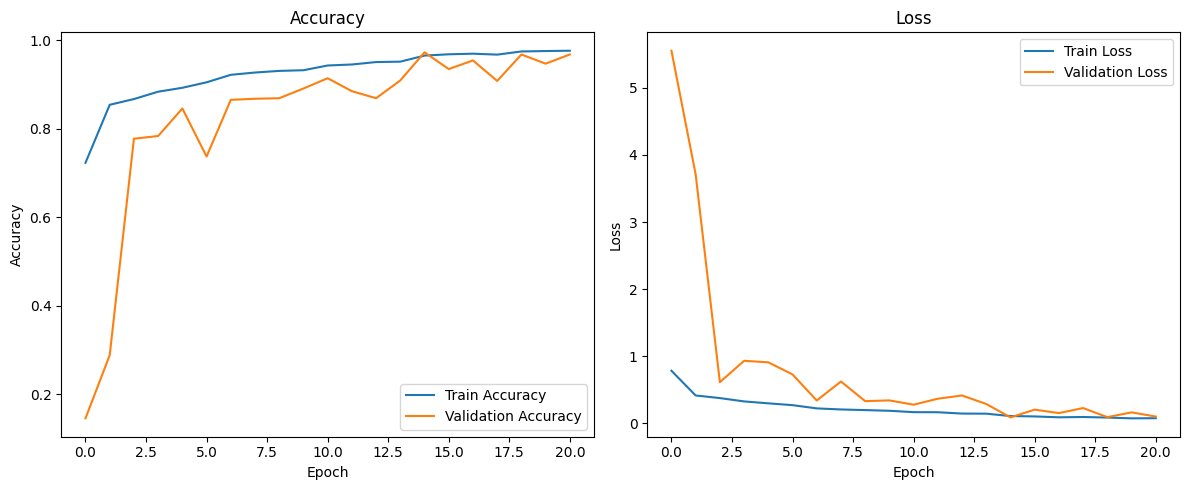

In [ ]:
# Training History Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "training_history.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
# Model Evaluation
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 684ms/step - accuracy: 0.9658 - loss: 0.0920
Test Loss: 0.0920
Test Accuracy: 0.9658


In [ ]:
# Performance Report
y_true, y_pred, y_conf = [], [], []

for images, labels in test_ds:
    probabilities = model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_conf.extend(confidences)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_conf = np.array(y_conf)

In [ ]:
# Classification Report
report_text = classification_report(y_true, y_pred, target_names=class_names)

print("\nClassification Report:\n")
print(report_text)

with open(os.path.join(metrics_dir, "classification_report.txt"), "w") as f:
    f.write(report_text)


Classification Report:

                 precision    recall  f1-score   support

  Fetal abdomen       0.88      0.94      0.91        71
    Fetal brain       1.00      0.98      0.99       310
    Fetal femur       0.91      0.98      0.94       104
   Fetal thorax       0.97      0.91      0.94       172
Maternal cervix       0.98      1.00      0.99       162

       accuracy                           0.97       819
      macro avg       0.95      0.96      0.95       819
   weighted avg       0.97      0.97      0.97       819



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n")
print(cm)

np.savetxt(os.path.join(metrics_dir, "confusion_matrix.txt"), cm, fmt="%d")

Confusion Matrix:

[[ 67   0   2   2   0]
 [  1 303   4   2   0]
 [  0   0 102   1   1]
 [  8   1   4 157   2]
 [  0   0   0   0 162]]


In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.close()

In [ ]:
# Specificity Calculation
print("\nClass-wise Specificity:\n")
specificity_scores = {}

for i, class_name in enumerate(class_names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity_scores[class_name] = specificity
    print(f"{class_name}: {specificity:.4f}")

macro_specificity = np.mean(list(specificity_scores.values()))
print(f"\nMacro-Average Specificity: {macro_specificity:.4f}")


Class-wise Specificity:

Fetal abdomen: 0.9880
Fetal brain: 0.9980
Fetal femur: 0.9860
Fetal thorax: 0.9923
Maternal cervix: 0.9954

Macro-Average Specificity: 0.9919


In [ ]:
# Confidence Score Report
print("\nConfidence Score Summary:\n")
average_confidence = np.mean(y_conf)
print(f"Average Confidence Score: {average_confidence:.4f}")

for i, class_name in enumerate(class_names):
    class_conf = y_conf[y_pred == i]
    if len(class_conf) > 0:
        print(f"{class_name}: Mean Confidence = {np.mean(class_conf):.4f}") 
    else:
        print(f"{class_name}: Mean Confidence = N/A")


Confidence Score Summary:

Average Confidence Score: 0.9682
Fetal abdomen: Mean Confidence = 0.9175
Fetal brain: Mean Confidence = 0.9813
Fetal femur: Mean Confidence = 0.9709
Fetal thorax: Mean Confidence = 0.9409
Maternal cervix: Mean Confidence = 0.9924


In [ ]:
# Save Metrics Summary
metrics_summary = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "macro_average_specificity": float(macro_specificity),
    "average_confidence_score": float(average_confidence)
}

for class_name, spec in specificity_scores.items():
    metrics_summary[f"specificity_{class_name}"] = float(spec)

with open(os.path.join(metrics_dir, "metrics_summary.json"), "w") as f:
    json.dump(metrics_summary, f, indent=4)

with open(os.path.join(metrics_dir, "metrics_summary.txt"), "w") as f:
    for key, value in metrics_summary.items():
        f.write(f"{key}: {value}\n")

In [ ]:
# Save Predictions CSV
pred_df = pd.DataFrame({
    "true_label_id": y_true,
    "predicted_label_id": y_pred,
    "true_label_name": [class_names[i] for i in y_true],
    "predicted_label_name": [class_names[i] for i in y_pred],
    "confidence_score": y_conf
})

pred_df.to_csv(os.path.join(predictions_dir, "test_predictions.csv"), index=False)

In [ ]:
# Model Saving
model.save(os.path.join(model_dir, "US_FetalPlane_Detection_Model.keras"))
print("Model saved successfully.")

Model saved successfully.


In [ ]:
print("\nAll outputs saved successfully.")
print(f"Output directory: {output_dir}")
print(f"Model directory: {model_dir}")
print(f"Plots directory: {plots_dir}")
print(f"Metrics directory: {metrics_dir}")
print(f"Predictions directory: {predictions_dir}")


All outputs saved successfully.
Output directory: Output
Model directory: Output\Model
Plots directory: Output\Plots
Metrics directory: Output\Metrics
Predictions directory: Output\Predictions
